# Clase 3 — Métodos Monte Carlo y Diferencias Temporales TD(0)

**Curso:** Aprendizaje por Refuerzo: Fundamentos y Aplicaciones
**Institución:** Universidad Austral — Facultad de Ingeniería (Posgrados)
**Docente:** Dr. Darío Ezequiel Díaz
**Fecha:** 19 de mayo de 2026

---

## Resumen del cuaderno

Este cuaderno acompaña la tercera clase del curso y aterriza en código los conceptos teóricos discutidos durante la sesión sincrónica. Se transita desde la programación dinámica exacta (Clase 2) hacia el aprendizaje a partir de la experiencia, abordando la pregunta vertebradora:

> **¿Cómo estimar $V^\pi$ cuando la dinámica $P$ es desconocida y solo disponemos de muestras de trayectorias?**

La estructura sigue, por orden, los bloques temáticos anunciados en la diapositiva del notebook:

1. **Entornos de trabajo**: GridWorld estocástico (laboratorio principal) y Random Walk de 5 estados (banco de pruebas teórico).
2. **Métodos Monte Carlo**: implementación de `first_visit_mc_prediction` y `every_visit_mc_prediction`.
3. **Diferencias Temporales TD(0)**: implementación de `td0_prediction` con paso constante.
4. **Réplica del experimento canónico** de Sutton & Barto (figura 6.2): convergencia comparada sobre el random walk.
5. **Análisis de sensibilidad al paso $\alpha$**: barrido sobre $\alpha \in \{0.01, 0.05, 0.1, 0.2\}$.
6. **Análisis de varianza**: $N = 500$ réplicas independientes con bandas de confianza al 95%.
7. **GridWorld**: visualización comparada del estimador $\widehat{V}$ y mapas de error respecto al valor verdadero.

> **Compatibilidad.** El cuaderno se ejecuta sin modificaciones tanto en un entorno local con Python 3.10+ como en Google Colab. No requiere GPU. Las únicas dependencias externas son `numpy`, `matplotlib` y `scipy`.

---

### Notación recurrente

| Símbolo | Significado |
|---------|-------------|
| $V^\pi(s)$ | Función de valor de estado bajo la política $\pi$ |
| $G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$ | Retorno descontado desde el paso $t$ |
| $\widehat{V}(s)$ | Estimador empírico de $V^\pi(s)$ |
| $\delta_t = R_{t+1} + \gamma \widehat{V}(S_{t+1}) - \widehat{V}(S_t)$ | TD-error en el paso $t$ |
| $\alpha$ | Paso de aprendizaje (learning rate) |
| $\gamma$ | Factor de descuento, $\gamma \in [0, 1)$ |

## Bloque 0 — Configuración del entorno

Importamos las bibliotecas necesarias y fijamos parámetros gráficos. Se establece una semilla global para garantizar reproducibilidad estricta de todos los experimentos del cuaderno.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import stats
from collections import defaultdict

# Reproducibilidad
SEMILLA_GLOBAL = 42
np.random.seed(SEMILLA_GLOBAL)

# Paleta institucional (consistente con Clases 1 y 2)
COLOR_NAVY = '#1E3A5F'
COLOR_ORANGE = '#D86A2C'
COLOR_TEAL = '#2E8A99'
COLOR_LIGHT_TEAL = '#9FD3D8'
COLOR_LIGHT_ORANGE = '#F2A06B'
COLOR_GRAY = '#4A4A4A'
COLOR_RED = '#B23A48'
COLOR_GREEN = '#2E7D5B'

# Estilo de figuras
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.titlecolor': COLOR_NAVY,
    'legend.fontsize': 10,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Configuración cargada correctamente.')

Configuración cargada correctamente.


## Bloque 1 — Entornos de trabajo

Construimos dos entornos canónicos. El primero, el **random walk de 5 estados**, posee valores teóricos cerrados que servirán como patrón áureo para evaluar el error de los estimadores. El segundo, el **GridWorld estocástico**, permite ilustrar los métodos en un escenario espacialmente interpretable.

### 1.1. Random walk de 5 estados (Sutton & Barto, sección 6.2)

**Descripción.** Cadena lineal $T_{\text{izq}} - A - B - C - D - E - T_{\text{der}}$ con dos estados terminales en los extremos. En cada paso, el agente se mueve a la izquierda o derecha con probabilidad $1/2$. La recompensa es $+1$ al alcanzar el terminal derecho y $0$ en cualquier otro caso. Factor de descuento $\gamma = 1$.

**Valores verdaderos** (probabilidad de absorber por el extremo derecho partiendo de cada estado interior):

$$V^\pi(A) = \tfrac{1}{6},\quad V^\pi(B) = \tfrac{2}{6},\quad V^\pi(C) = \tfrac{3}{6},\quad V^\pi(D) = \tfrac{4}{6},\quad V^\pi(E) = \tfrac{5}{6}.$$

Estos valores constituyen la referencia exacta contra la que mediremos el error de Monte Carlo y TD(0).

In [2]:
class RandomWalk:
    '''
    Cadena de Markov lineal de cinco estados interiores con dos terminales.

    Estados internos: 0=A, 1=B, 2=C, 3=D, 4=E.
    Estado inicial fijo: C (indice 2).
    Acciones: 0=izquierda, 1=derecha; politica uniforme.
    Recompensa: +1 al absorber por la derecha, 0 en cualquier otro caso.
    '''

    def __init__(self):
        self.n_estados = 5
        self.estado_inicial = 2  # C
        self.estados = list(range(self.n_estados))
        # Valores teoricos cerrados
        self.V_verdadero = np.array([1/6, 2/6, 3/6, 4/6, 5/6])

    def reset(self, rng):
        return self.estado_inicial

    def paso(self, estado, rng):
        '''
        Devuelve (estado_siguiente, recompensa, terminal).
        El estado siguiente es -1 si se absorbio por la izquierda y
        n_estados (5) si se absorbio por la derecha.
        '''
        accion = rng.integers(2)  # 0 o 1 uniformemente
        if accion == 0:
            siguiente = estado - 1
            recompensa = 0.0
        else:
            siguiente = estado + 1
            recompensa = 1.0 if siguiente == self.n_estados else 0.0

        terminal = (siguiente < 0) or (siguiente >= self.n_estados)
        return siguiente, recompensa, terminal


rw = RandomWalk()
print(f'Random walk: {rw.n_estados} estados internos.')
print(f'Valores verdaderos: {rw.V_verdadero}')
print(f'Estado inicial: C (indice {rw.estado_inicial})')

Random walk: 5 estados internos.
Valores verdaderos: [0.16666667 0.33333333 0.5        0.66666667 0.83333333]
Estado inicial: C (indice 2)


### 1.2. GridWorld estocástico

Reutilizamos el GridWorld de la Clase 2, **introduciendo estocasticidad de transición**: con probabilidad $1-p_{\text{slip}}$ el movimiento es el indicado por la acción; con probabilidad $p_{\text{slip}}$ el agente se desvía ortogonalmente (resbala). Este detalle, aparentemente menor, tiene un efecto sustantivo sobre la varianza de $G_t$ y, por tanto, sobre la convergencia de los estimadores.

In [3]:
class GridWorldEstocastico:
    '''
    GridWorld 4x4 con muros y transiciones estocasticas.

    Acciones: 0=arriba, 1=derecha, 2=abajo, 3=izquierda.
    Con probabilidad (1 - p_slip), la accion elegida se ejecuta;
    con probabilidad p_slip, el agente se desvia ortogonalmente
    (con igual probabilidad hacia cada uno de los dos lados).
    '''

    def __init__(self, n_filas=4, n_cols=4, muros=None,
                 inicio=(3, 0), meta=(0, 3),
                 recompensa_paso=-0.04, recompensa_meta=1.0,
                 p_slip=0.1):
        self.n_filas = n_filas
        self.n_cols = n_cols
        self.muros = set(muros) if muros else set()
        self.inicio = inicio
        self.meta = meta
        self.recompensa_paso = recompensa_paso
        self.recompensa_meta = recompensa_meta
        self.p_slip = p_slip

        self.acciones = [(-1, 0), (0, 1), (1, 0), (0, -1)]
        self.nombres_acciones = ['arriba', 'derecha', 'abajo', 'izquierda']

        self.estados = [(r, c) for r in range(n_filas)
                        for c in range(n_cols)
                        if (r, c) not in self.muros]
        self.idx_estado = {s: i for i, s in enumerate(self.estados)}
        self.n_estados = len(self.estados)
        self.n_acciones = len(self.acciones)

    def _aplicar_movimiento(self, estado, dr, dc):
        nr, nc = estado[0] + dr, estado[1] + dc
        fuera = (nr < 0 or nr >= self.n_filas or
                 nc < 0 or nc >= self.n_cols)
        if fuera or (nr, nc) in self.muros:
            return estado
        return (nr, nc)

    def paso(self, estado, accion, rng):
        '''
        Aplica la accion con estocasticidad y devuelve
        (estado_siguiente, recompensa, terminal).
        '''
        if estado == self.meta:
            return estado, 0.0, True

        # Decision estocastica: 1-p_slip ejecuta accion, p_slip se desvia
        if rng.random() < self.p_slip:
            ortogonales = [(accion + 1) % 4, (accion - 1) % 4]
            accion_real = rng.choice(ortogonales)
        else:
            accion_real = accion

        dr, dc = self.acciones[accion_real]
        siguiente = self._aplicar_movimiento(estado, dr, dc)

        if siguiente == self.meta:
            return siguiente, self.recompensa_meta, True
        return siguiente, self.recompensa_paso, False

    def reset(self, rng):
        return self.inicio


gw = GridWorldEstocastico(muros={(2, 1), (2, 2)}, p_slip=0.1)
print(f'GridWorld estocastico: {gw.n_estados} estados, {gw.n_acciones} acciones.')
print(f'Probabilidad de deslizamiento: {gw.p_slip:.2f}')
print(f'Inicio: {gw.inicio}, Meta: {gw.meta}')

GridWorld estocastico: 14 estados, 4 acciones.
Probabilidad de deslizamiento: 0.10
Inicio: (3, 0), Meta: (0, 3)


### 1.3. Función auxiliar: generación de episodios

Esta función, abstracta respecto del entorno y la política, será el motor de muestreo de todos los algoritmos del cuaderno. Devuelve una trayectoria como lista de tuplas `(estado, recompensa)`.

In [4]:
def generar_episodio_random_walk(env, rng, max_pasos=1000):
    '''Genera un episodio en el random walk con politica uniforme.'''
    trayectoria = []
    estado = env.reset(rng)
    for _ in range(max_pasos):
        siguiente, r, terminal = env.paso(estado, rng)
        trayectoria.append((estado, r))
        if terminal:
            break
        estado = siguiente
    return trayectoria


def generar_episodio_gridworld(env, politica, rng, max_pasos=500):
    '''
    Genera un episodio en GridWorld siguiendo una politica
    estocastica representada como matriz (n_estados, n_acciones).
    Devuelve trayectoria como lista de tuplas (indice_estado, recompensa).
    '''
    trayectoria = []
    estado = env.reset(rng)
    for _ in range(max_pasos):
        idx = env.idx_estado[estado]
        accion = rng.choice(env.n_acciones, p=politica[idx])
        siguiente, r, terminal = env.paso(estado, accion, rng)
        trayectoria.append((idx, r))
        if terminal:
            break
        estado = siguiente
    return trayectoria


# Prueba: episodio en random walk
rng_demo = np.random.default_rng(SEMILLA_GLOBAL)
ep_demo = generar_episodio_random_walk(rw, rng_demo)
print(f'Longitud del episodio: {len(ep_demo)} transiciones')
print(f'Primeros estados visitados: {[t[0] for t in ep_demo[:10]]}')
print(f'Recompensa terminal: {ep_demo[-1][1]}')

Longitud del episodio: 15 transiciones
Primeros estados visitados: [2, 1, 2, 3, 2, 1, 2, 1, 2, 1]
Recompensa terminal: 1.0


## Bloque 2 — Métodos Monte Carlo para la predicción

Implementamos las dos variantes clásicas:

* **First-visit MC**: promedia el retorno asociado únicamente a la primera ocurrencia de cada estado en un episodio.
* **Every-visit MC**: promedia los retornos de todas las visitas.

Ambas son consistentes; sus muestras subyacentes difieren (independientes vs. correlacionadas), motivo por el cual first-visit es la variante más estudiada en términos teóricos.

### 2.1. Implementación incremental

Para evitar mantener todos los retornos en memoria, empleamos la fórmula recursiva del promedio muestral:

$$\widehat{V}_{n+1}(s) = \widehat{V}_n(s) + \frac{1}{n+1}\left[G_{n+1} - \widehat{V}_n(s)\right].$$

Equivalentemente, en forma de actualización tipo aproximación estocástica con paso $\alpha_n = 1/n$:

$$\widehat{V}(s) \leftarrow \widehat{V}(s) + \alpha_n\left[G - \widehat{V}(s)\right].$$

In [5]:
def first_visit_mc_prediction(env, generador_episodio, n_estados,
                              n_episodios, gamma=1.0, semilla=0,
                              registrar_progreso=False, V_verdadero=None):
    '''
    Estimacion first-visit Monte Carlo del valor V^pi.

    Parametros
    ----------
    env : entorno con interfaz reset() y paso()
    generador_episodio : funcion que produce una trayectoria
    n_estados : tamano del espacio de estados (indices 0..n-1)
    n_episodios : numero de episodios a simular
    gamma : factor de descuento
    semilla : semilla del generador aleatorio
    registrar_progreso : si True, guarda la evolucion de V tras cada episodio
    V_verdadero : si se proporciona, calcula error RMS en cada paso

    Devuelve
    --------
    V_hat : ndarray con el estimador final
    historial : dict con 'V_por_episodio' (opcional) y 'rms'
    '''
    rng = np.random.default_rng(semilla)
    V_hat = np.zeros(n_estados)
    conteo = np.zeros(n_estados, dtype=int)

    historial = {'rms': [], 'V_por_episodio': []}

    for e in range(n_episodios):
        episodio = generador_episodio(env, rng)

        # Calculo del retorno hacia atras: para first-visit, al iterar al reves
        # y sobrescribir, queda registrado el G correspondiente al primer t en
        # que cada estado aparece (porque sobrescribimos a medida que retrocedemos)
        G = 0.0
        retornos_visita = {}
        for t in range(len(episodio) - 1, -1, -1):
            estado, r = episodio[t]
            G = gamma * G + r
            retornos_visita[estado] = G

        for estado, G_primera in retornos_visita.items():
            conteo[estado] += 1
            V_hat[estado] += (G_primera - V_hat[estado]) / conteo[estado]

        if V_verdadero is not None:
            rms = np.sqrt(np.mean((V_hat - V_verdadero)**2))
            historial['rms'].append(rms)
        if registrar_progreso:
            historial['V_por_episodio'].append(V_hat.copy())

    return V_hat, historial

In [6]:
def every_visit_mc_prediction(env, generador_episodio, n_estados,
                              n_episodios, gamma=1.0, semilla=0,
                              registrar_progreso=False, V_verdadero=None):
    '''
    Estimacion every-visit Monte Carlo del valor V^pi.
    Promedia los retornos sobre TODAS las visitas a cada estado.
    '''
    rng = np.random.default_rng(semilla)
    V_hat = np.zeros(n_estados)
    conteo = np.zeros(n_estados, dtype=int)

    historial = {'rms': [], 'V_por_episodio': []}

    for e in range(n_episodios):
        episodio = generador_episodio(env, rng)

        # Calcular retornos para cada paso
        G = 0.0
        retornos_paso = []
        for t in range(len(episodio) - 1, -1, -1):
            estado, r = episodio[t]
            G = gamma * G + r
            retornos_paso.append((estado, G))
        retornos_paso.reverse()

        # Actualizar V para cada visita (incremental por paso)
        for estado, G_t in retornos_paso:
            conteo[estado] += 1
            V_hat[estado] += (G_t - V_hat[estado]) / conteo[estado]

        if V_verdadero is not None:
            rms = np.sqrt(np.mean((V_hat - V_verdadero)**2))
            historial['rms'].append(rms)
        if registrar_progreso:
            historial['V_por_episodio'].append(V_hat.copy())

    return V_hat, historial

### 2.2. Prueba rápida sobre el random walk

Ejecutamos 1000 episodios y comparamos con los valores verdaderos. La discrepancia debe ser pequeña gracias a la consistencia del estimador.

In [7]:
# Wrapper para que el generador reciba env como argumento posicional
gen_rw = lambda env, rng: generar_episodio_random_walk(env, rng)

V_fv, _ = first_visit_mc_prediction(rw, gen_rw, rw.n_estados,
                                    n_episodios=1000, gamma=1.0,
                                    semilla=SEMILLA_GLOBAL)
V_ev, _ = every_visit_mc_prediction(rw, gen_rw, rw.n_estados,
                                    n_episodios=1000, gamma=1.0,
                                    semilla=SEMILLA_GLOBAL)

print('Random walk - Estimacion tras 1000 episodios')
print(f'{"Estado":<8}{"Verdadero":<12}{"First-visit":<14}{"Every-visit":<14}')
print('-' * 48)
for i, etq in enumerate(['A', 'B', 'C', 'D', 'E']):
    print(f'{etq:<8}{rw.V_verdadero[i]:<12.4f}{V_fv[i]:<14.4f}{V_ev[i]:<14.4f}')

rms_fv = np.sqrt(np.mean((V_fv - rw.V_verdadero)**2))
rms_ev = np.sqrt(np.mean((V_ev - rw.V_verdadero)**2))
print(f'\nRMS first-visit: {rms_fv:.5f}')
print(f'RMS every-visit: {rms_ev:.5f}')

Random walk - Estimacion tras 1000 episodios
Estado  Verdadero   First-visit   Every-visit   
------------------------------------------------
A       0.1667      0.1661        0.1629        
B       0.3333      0.3233        0.3227        
C       0.5000      0.4830        0.4858        
D       0.6667      0.6518        0.6621        
E       0.8333      0.8271        0.8387        

RMS first-visit: 0.01140
RMS every-visit: 0.00870


## Bloque 3 — Diferencias Temporales TD(0)

La actualización canónica:

$$\widehat{V}(S_t) \leftarrow \widehat{V}(S_t) + \alpha\left[R_{t+1} + \gamma \widehat{V}(S_{t+1}) - \widehat{V}(S_t)\right].$$

A diferencia de Monte Carlo, **no es necesario esperar el final del episodio**: la actualización se produce tras cada transición. Esta característica vuelve TD(0) aplicable a tareas continuas y, como veremos, le confiere ventaja en eficiencia muestral cuando el horizonte temporal es largo.

### 3.1. Implementación tabular

In [8]:
def td0_prediction(env, n_estados, n_episodios, alpha=0.1, gamma=1.0,
                   semilla=0, V_inicial=None, V_verdadero=None,
                   politica=None, modo='random_walk'):
    '''
    Aprendizaje TD(0) tabular para prediccion.

    Parametros
    ----------
    env : entorno
    n_estados : tamano del espacio de estados
    n_episodios : numero de episodios a simular
    alpha : paso de aprendizaje constante
    gamma : factor de descuento
    semilla : semilla del generador aleatorio
    V_inicial : valores iniciales (default: ceros)
    V_verdadero : referencia para computo de RMS
    politica : matriz (n_estados, n_acciones) para GridWorld
    modo : 'random_walk' o 'gridworld'

    Devuelve V_hat e historial.
    '''
    rng = np.random.default_rng(semilla)
    V_hat = np.zeros(n_estados) if V_inicial is None else V_inicial.copy()
    historial = {'rms': []}

    for e in range(n_episodios):
        estado = env.reset(rng)

        while True:
            if modo == 'random_walk':
                siguiente, r, terminal = env.paso(estado, rng)
                idx_s = estado
                v_siguiente = 0.0 if terminal else V_hat[siguiente]
            else:  # gridworld
                idx_s = env.idx_estado[estado]
                accion = rng.choice(env.n_acciones, p=politica[idx_s])
                siguiente, r, terminal = env.paso(estado, accion, rng)
                if terminal:
                    v_siguiente = 0.0
                else:
                    v_siguiente = V_hat[env.idx_estado[siguiente]]

            # Actualizacion TD(0)
            td_error = r + gamma * v_siguiente - V_hat[idx_s]
            V_hat[idx_s] += alpha * td_error

            if terminal:
                break
            estado = siguiente

        if V_verdadero is not None:
            rms = np.sqrt(np.mean((V_hat - V_verdadero)**2))
            historial['rms'].append(rms)

    return V_hat, historial

### 3.2. Prueba rápida sobre el random walk

Comparamos TD(0) con tres valores del paso de aprendizaje. Inicializamos $\widehat{V}_0(s) = 0.5$ para todos los estados, siguiendo la convención de Sutton & Barto (sección 6.2): punto medio entre los dos extremos posibles del retorno.

In [9]:
V0 = np.full(rw.n_estados, 0.5)

resultados_td = {}
for alpha in [0.05, 0.10, 0.15]:
    V_td, _ = td0_prediction(rw, rw.n_estados, n_episodios=1000,
                             alpha=alpha, gamma=1.0,
                             semilla=SEMILLA_GLOBAL,
                             V_inicial=V0.copy(),
                             modo='random_walk')
    resultados_td[alpha] = V_td

print('Random walk - TD(0) tras 1000 episodios')
print(f'{"Estado":<8}{"Verdadero":<12}{"alpha=0.05":<12}{"alpha=0.10":<12}{"alpha=0.15":<12}')
print('-' * 56)
for i, etq in enumerate(['A', 'B', 'C', 'D', 'E']):
    fila = f'{etq:<8}{rw.V_verdadero[i]:<12.4f}'
    for a in [0.05, 0.10, 0.15]:
        fila += f'{resultados_td[a][i]:<12.4f}'
    print(fila)

Random walk - TD(0) tras 1000 episodios
Estado  Verdadero   alpha=0.05  alpha=0.10  alpha=0.15  
--------------------------------------------------------
A       0.1667      0.1820      0.1853      0.1763      
B       0.3333      0.3441      0.3490      0.3416      
C       0.5000      0.5209      0.5663      0.5884      
D       0.6667      0.6960      0.7327      0.7530      
E       0.8333      0.8560      0.8791      0.8893      


## Bloque 4 — Réplica del experimento canónico (Sutton & Barto, figura 6.2)

Reproducimos el experimento más célebre del capítulo 6: la comparación del error RMS de Monte Carlo (con varios $\alpha$) y TD(0) (con varios $\alpha$) sobre el random walk, promediando el error sobre 100 corridas independientes.

**Interpretación esperada**: TD(0) reduce el error más rápidamente para pasos moderados; Monte Carlo se comporta mejor para $\alpha$ pequeños pero requiere muchos más episodios.

In [10]:
def correr_replicas(metodo, kwargs_metodo, n_replicas, semilla_base):
    '''
    Ejecuta n_replicas independientes y devuelve la matriz de errores RMS:
    matriz[i, e] = RMS en replica i tras episodio e.
    '''
    n_episodios = kwargs_metodo['n_episodios']
    matriz = np.zeros((n_replicas, n_episodios))
    for i in range(n_replicas):
        kw = dict(kwargs_metodo)
        kw['semilla'] = semilla_base + i
        _, hist = metodo(**kw)
        matriz[i, :] = hist['rms']
    return matriz


N_REPLICAS = 100
N_EPISODIOS = 100

# Argumentos comunes
arg_comun = dict(env=rw, n_estados=rw.n_estados,
                 n_episodios=N_EPISODIOS, gamma=1.0,
                 V_verdadero=rw.V_verdadero)

mc_alphas_constantes = [0.01, 0.02, 0.03, 0.04]
resultados_mc_const = {}
for alpha in mc_alphas_constantes:
    print(f'MC con alpha constante = {alpha} ...', end=' ')
    rms_matriz = np.zeros((N_REPLICAS, N_EPISODIOS))
    for i in range(N_REPLICAS):
        rng = np.random.default_rng(SEMILLA_GLOBAL + i)
        V_hat = np.full(rw.n_estados, 0.5)
        for e in range(N_EPISODIOS):
            episodio = generar_episodio_random_walk(rw, rng)
            G = 0.0
            primeros = {}
            for t in range(len(episodio) - 1, -1, -1):
                s, r = episodio[t]
                G = G + r  # gamma=1
                primeros[s] = G
            for s, Gs in primeros.items():
                V_hat[s] += alpha * (Gs - V_hat[s])
            rms_matriz[i, e] = np.sqrt(np.mean((V_hat - rw.V_verdadero)**2))
    resultados_mc_const[alpha] = rms_matriz
    print('OK')

resultados_td_const = {}
td_alphas = [0.05, 0.10, 0.15]
for alpha in td_alphas:
    print(f'TD(0) con alpha = {alpha} ...', end=' ')
    arg_td = dict(arg_comun, alpha=alpha, V_inicial=np.full(rw.n_estados, 0.5),
                  modo='random_walk')
    rms_matriz = correr_replicas(td0_prediction, arg_td, N_REPLICAS, SEMILLA_GLOBAL)
    resultados_td_const[alpha] = rms_matriz
    print('OK')

print('\nTodas las replicas completadas.')

MC con alpha constante = 0.01 ... 

OK
MC con alpha constante = 0.02 ... 

OK
MC con alpha constante = 0.03 ... 

OK
MC con alpha constante = 0.04 ... 

OK
TD(0) con alpha = 0.05 ... 

OK
TD(0) con alpha = 0.1 ... 

OK
TD(0) con alpha = 0.15 ... 

OK

Todas las replicas completadas.


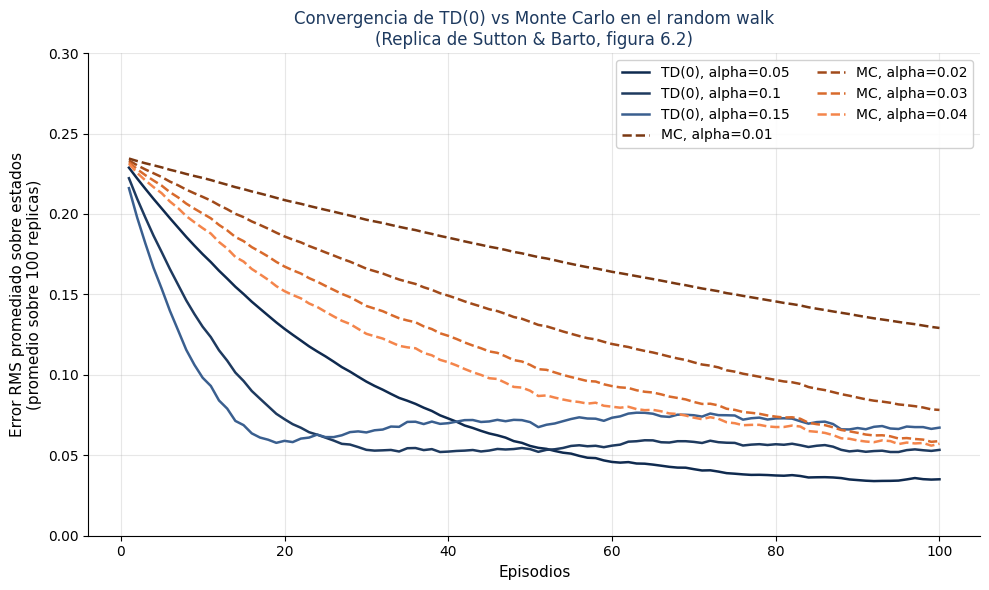


Lectura: TD(0) con pasos moderados converge mas rapido.
MC con alpha pequenos es mas estable a largo plazo pero mas lento al inicio.


In [11]:
# Figura: convergencia comparada
fig, ax = plt.subplots(figsize=(10, 6))

colores_td = ['#0F2A4F', COLOR_NAVY, '#3A5F8F']
for alpha, color in zip(td_alphas, colores_td):
    media = resultados_td_const[alpha].mean(axis=0)
    ax.plot(range(1, N_EPISODIOS + 1), media,
            color=color, linewidth=1.8, label=f'TD(0), alpha={alpha}')

colores_mc = ['#7A3812', '#A14A1A', COLOR_ORANGE, '#F4854B']
for alpha, color in zip(mc_alphas_constantes, colores_mc):
    media = resultados_mc_const[alpha].mean(axis=0)
    ax.plot(range(1, N_EPISODIOS + 1), media,
            color=color, linewidth=1.8, linestyle='--',
            label=f'MC, alpha={alpha}')

ax.set_xlabel('Episodios')
ax.set_ylabel('Error RMS promediado sobre estados\n(promedio sobre 100 replicas)')
ax.set_title('Convergencia de TD(0) vs Monte Carlo en el random walk\n(Replica de Sutton & Barto, figura 6.2)')
ax.legend(loc='upper right', frameon=True, framealpha=0.9, ncol=2)
ax.grid(alpha=0.3)
ax.set_ylim(0, 0.30)
plt.tight_layout()
plt.show()

print('\nLectura: TD(0) con pasos moderados converge mas rapido.')
print('MC con alpha pequenos es mas estable a largo plazo pero mas lento al inicio.')

## Bloque 5 — Análisis de sensibilidad al paso $\alpha$

¿Existe un $\alpha^*$ que minimice el error RMS asintótico? Esta pregunta tiene relevancia metodológica: el ajuste del paso es uno de los hiperparámetros más sensibles en la práctica del RL.

Realizamos un barrido fino sobre $\alpha \in \{0.01, 0.05, 0.10, 0.15, 0.20, 0.30\}$ y reportamos el error RMS final tras 100 episodios, promediado sobre 100 réplicas independientes.

In [12]:
alphas_barrido = [0.01, 0.05, 0.10, 0.15, 0.20, 0.30]
N_REP_BARRIDO = 100
N_EP_BARRIDO = 100

rms_finales_td = {}
rms_finales_mc = {}

for alpha in alphas_barrido:
    arg_td = dict(env=rw, n_estados=rw.n_estados,
                  n_episodios=N_EP_BARRIDO, gamma=1.0, alpha=alpha,
                  V_inicial=np.full(rw.n_estados, 0.5),
                  V_verdadero=rw.V_verdadero, modo='random_walk')
    matriz_td = correr_replicas(td0_prediction, arg_td, N_REP_BARRIDO, SEMILLA_GLOBAL)
    rms_finales_td[alpha] = matriz_td[:, -1]

    rms_mc_final = []
    for i in range(N_REP_BARRIDO):
        rng = np.random.default_rng(SEMILLA_GLOBAL + i)
        V_hat = np.full(rw.n_estados, 0.5)
        for e in range(N_EP_BARRIDO):
            episodio = generar_episodio_random_walk(rw, rng)
            G = 0.0
            primeros = {}
            for t in range(len(episodio) - 1, -1, -1):
                s, r = episodio[t]
                G = G + r
                primeros[s] = G
            for s, Gs in primeros.items():
                V_hat[s] += alpha * (Gs - V_hat[s])
        rms_mc_final.append(np.sqrt(np.mean((V_hat - rw.V_verdadero)**2)))
    rms_finales_mc[alpha] = np.array(rms_mc_final)

print('Barrido sobre alpha completado.')

Barrido sobre alpha completado.


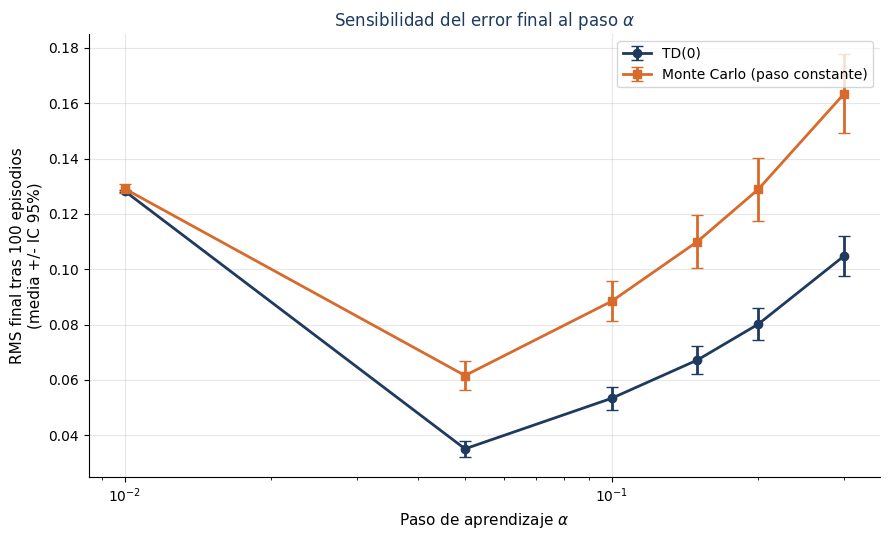


alpha optimo TD(0): 0.05, RMS = 0.0351
alpha optimo MC:    0.05, RMS = 0.0616


In [13]:
fig, ax = plt.subplots(figsize=(9, 5.5))

medias_td = [rms_finales_td[a].mean() for a in alphas_barrido]
medias_mc = [rms_finales_mc[a].mean() for a in alphas_barrido]
errs_td = [1.96 * rms_finales_td[a].std() / np.sqrt(N_REP_BARRIDO) for a in alphas_barrido]
errs_mc = [1.96 * rms_finales_mc[a].std() / np.sqrt(N_REP_BARRIDO) for a in alphas_barrido]

ax.errorbar(alphas_barrido, medias_td, yerr=errs_td,
            color=COLOR_NAVY, marker='o', linewidth=2,
            capsize=4, label='TD(0)')
ax.errorbar(alphas_barrido, medias_mc, yerr=errs_mc,
            color=COLOR_ORANGE, marker='s', linewidth=2,
            capsize=4, label='Monte Carlo (paso constante)')

ax.set_xlabel(r'Paso de aprendizaje $\alpha$')
ax.set_ylabel(f'RMS final tras {N_EP_BARRIDO} episodios\n(media +/- IC 95%)')
ax.set_title(r'Sensibilidad del error final al paso $\alpha$')
ax.legend(loc='upper right', frameon=True)
ax.grid(alpha=0.3)
ax.set_xscale('log')
plt.tight_layout()
plt.show()

alpha_opt_td = alphas_barrido[np.argmin(medias_td)]
alpha_opt_mc = alphas_barrido[np.argmin(medias_mc)]
print(f'\nalpha optimo TD(0): {alpha_opt_td}, RMS = {min(medias_td):.4f}')
print(f'alpha optimo MC:    {alpha_opt_mc}, RMS = {min(medias_mc):.4f}')

## Bloque 6 — Análisis de varianza con N=500 réplicas

Para caracterizar formalmente la incertidumbre del estimador, escalamos el experimento a $N = 500$ réplicas independientes. Esto permite construir bandas de confianza de tipo bootstrap-percentil y compararlas con la aproximación gaussiana de IC al 95%.

In [14]:
N_GRANDE = 500
N_EP_GRANDE = 50

arg_td_grande = dict(env=rw, n_estados=rw.n_estados,
                     n_episodios=N_EP_GRANDE, gamma=1.0, alpha=0.10,
                     V_inicial=np.full(rw.n_estados, 0.5),
                     V_verdadero=rw.V_verdadero, modo='random_walk')

matriz_td_grande = correr_replicas(td0_prediction, arg_td_grande,
                                   N_GRANDE, SEMILLA_GLOBAL)

matriz_mc_grande = np.zeros((N_GRANDE, N_EP_GRANDE))
alpha_mc = 0.02
for i in range(N_GRANDE):
    rng = np.random.default_rng(SEMILLA_GLOBAL + i)
    V_hat = np.full(rw.n_estados, 0.5)
    for e in range(N_EP_GRANDE):
        episodio = generar_episodio_random_walk(rw, rng)
        G = 0.0
        primeros = {}
        for t in range(len(episodio) - 1, -1, -1):
            s, r = episodio[t]
            G = G + r
            primeros[s] = G
        for s, Gs in primeros.items():
            V_hat[s] += alpha_mc * (Gs - V_hat[s])
        matriz_mc_grande[i, e] = np.sqrt(np.mean((V_hat - rw.V_verdadero)**2))

print(f'Replicas N=500 completadas.')

Replicas N=500 completadas.


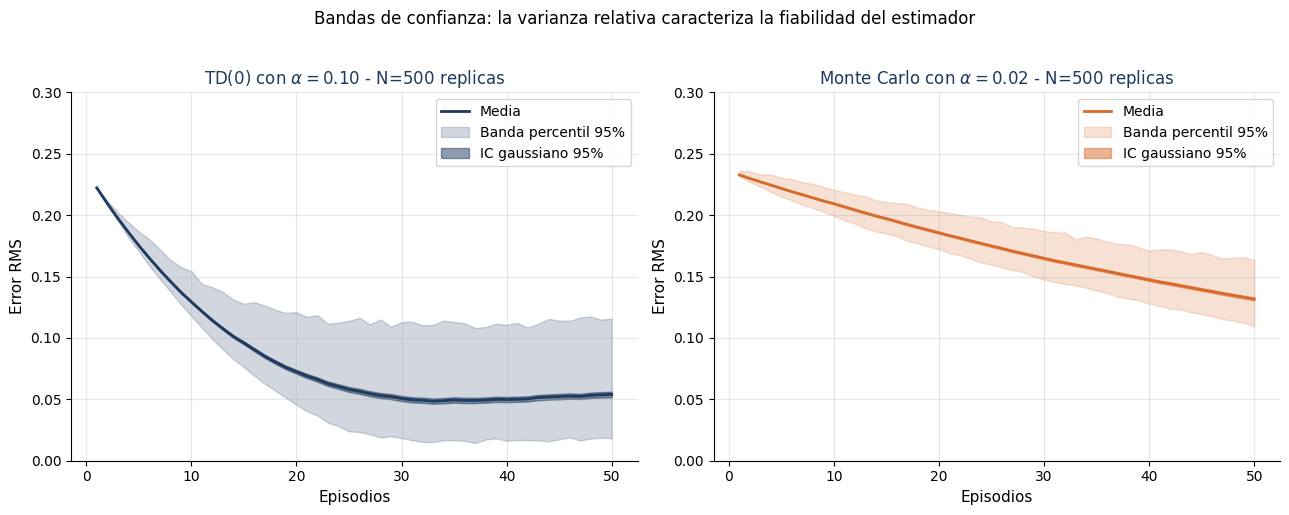


Desvio estandar final TD(0): 0.0259
Desvio estandar final MC:    0.0131


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(1, N_EP_GRANDE + 1)

media_td = matriz_td_grande.mean(axis=0)
q025_td = np.percentile(matriz_td_grande, 2.5, axis=0)
q975_td = np.percentile(matriz_td_grande, 97.5, axis=0)
std_td = matriz_td_grande.std(axis=0)

axes[0].plot(x, media_td, color=COLOR_NAVY, linewidth=2, label='Media')
axes[0].fill_between(x, q025_td, q975_td, color=COLOR_NAVY, alpha=0.2,
                     label='Banda percentil 95%')
axes[0].fill_between(x, media_td - 1.96*std_td/np.sqrt(N_GRANDE),
                     media_td + 1.96*std_td/np.sqrt(N_GRANDE),
                     color=COLOR_NAVY, alpha=0.5, label='IC gaussiano 95%')
axes[0].set_title(r'TD(0) con $\alpha = 0.10$ - N=500 replicas')
axes[0].set_xlabel('Episodios')
axes[0].set_ylabel('Error RMS')
axes[0].legend(loc='upper right', frameon=True)
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 0.30)

media_mc = matriz_mc_grande.mean(axis=0)
q025_mc = np.percentile(matriz_mc_grande, 2.5, axis=0)
q975_mc = np.percentile(matriz_mc_grande, 97.5, axis=0)
std_mc = matriz_mc_grande.std(axis=0)

axes[1].plot(x, media_mc, color=COLOR_ORANGE, linewidth=2, label='Media')
axes[1].fill_between(x, q025_mc, q975_mc, color=COLOR_ORANGE, alpha=0.2,
                     label='Banda percentil 95%')
axes[1].fill_between(x, media_mc - 1.96*std_mc/np.sqrt(N_GRANDE),
                     media_mc + 1.96*std_mc/np.sqrt(N_GRANDE),
                     color=COLOR_ORANGE, alpha=0.5, label='IC gaussiano 95%')
axes[1].set_title(r'Monte Carlo con $\alpha = 0.02$ - N=500 replicas')
axes[1].set_xlabel('Episodios')
axes[1].set_ylabel('Error RMS')
axes[1].legend(loc='upper right', frameon=True)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 0.30)

plt.suptitle('Bandas de confianza: la varianza relativa caracteriza la fiabilidad del estimador',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

print(f'\nDesvio estandar final TD(0): {std_td[-1]:.4f}')
print(f'Desvio estandar final MC:    {std_mc[-1]:.4f}')

## Bloque 7 — Aplicación al GridWorld estocástico

Cerramos el cuaderno migrando los métodos al GridWorld estocástico para mostrarlos en un entorno de varias dimensiones. La política $\pi$ que evaluamos es **uniforme aleatoria** (probabilidad $1/4$ para cada acción). Comparamos:

1. El valor verdadero $V^\pi$ obtenido por **inversión exacta** $V^\pi = (I - \gamma P^\pi)^{-1} R^\pi$.
2. La estimación $\widehat{V}^{\text{MC}}$ por Monte Carlo first-visit.
3. La estimación $\widehat{V}^{\text{TD}}$ por TD(0).

### 7.1. Cálculo del valor verdadero por inversión exacta

In [16]:
def calcular_dinamica_inducida_gridworld(env, politica):
    '''
    Construye P^pi y R^pi para el GridWorld estocastico, marginalizando
    sobre acciones y considerando la estocasticidad de transicion.
    '''
    n = env.n_estados
    P_pi = np.zeros((n, n))
    R_pi = np.zeros(n)

    for s in env.estados:
        i = env.idx_estado[s]
        if s == env.meta:
            P_pi[i, i] = 1.0
            continue

        for a in range(env.n_acciones):
            pi_sa = politica[i, a]
            destinos = [
                (1 - env.p_slip, a),
                (env.p_slip / 2, (a + 1) % 4),
                (env.p_slip / 2, (a - 1) % 4),
            ]
            for prob_accion, a_real in destinos:
                dr, dc = env.acciones[a_real]
                s_prima = env._aplicar_movimiento(s, dr, dc)
                j = env.idx_estado[s_prima]
                if s_prima == env.meta:
                    r = env.recompensa_meta
                else:
                    r = env.recompensa_paso
                P_pi[i, j] += pi_sa * prob_accion
                R_pi[i] += pi_sa * prob_accion * r

    return P_pi, R_pi


politica_uniforme = np.full((gw.n_estados, gw.n_acciones), 1.0 / gw.n_acciones)

gamma = 0.95
P_pi, R_pi = calcular_dinamica_inducida_gridworld(gw, politica_uniforme)
V_verdadero_gw = np.linalg.solve(np.eye(gw.n_estados) - gamma * P_pi, R_pi)

print(f'Valor exacto calculado para los {gw.n_estados} estados del GridWorld.')
print(f'V*(inicio) = {V_verdadero_gw[gw.idx_estado[gw.inicio]]:.4f}')
print(f'V*(meta)   = {V_verdadero_gw[gw.idx_estado[gw.meta]]:.4f}')

Valor exacto calculado para los 14 estados del GridWorld.
V*(inicio) = -0.5210
V*(meta)   = -0.0000


### 7.2. Estimación por MC y TD(0)

In [17]:
def gen_gw(env, rng):
    return generar_episodio_gridworld(env, politica_uniforme, rng, max_pasos=500)

N_EP_GW = 5000

V_mc_gw, _ = first_visit_mc_prediction(gw, gen_gw, gw.n_estados,
                                       n_episodios=N_EP_GW, gamma=gamma,
                                       semilla=SEMILLA_GLOBAL)

V_td_gw, _ = td0_prediction(gw, gw.n_estados, n_episodios=N_EP_GW,
                            alpha=0.1, gamma=gamma,
                            semilla=SEMILLA_GLOBAL,
                            politica=politica_uniforme,
                            modo='gridworld')

print(f'GridWorld - tras {N_EP_GW} episodios:')
print(f'V_MC(inicio)        = {V_mc_gw[gw.idx_estado[gw.inicio]]:.4f}')
print(f'V_TD(inicio)        = {V_td_gw[gw.idx_estado[gw.inicio]]:.4f}')
print(f'V_verdadero(inicio) = {V_verdadero_gw[gw.idx_estado[gw.inicio]]:.4f}')

GridWorld - tras 5000 episodios:
V_MC(inicio)        = -0.5313
V_TD(inicio)        = -0.5504
V_verdadero(inicio) = -0.5210


/tmp/ipykernel_849/3867148456.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


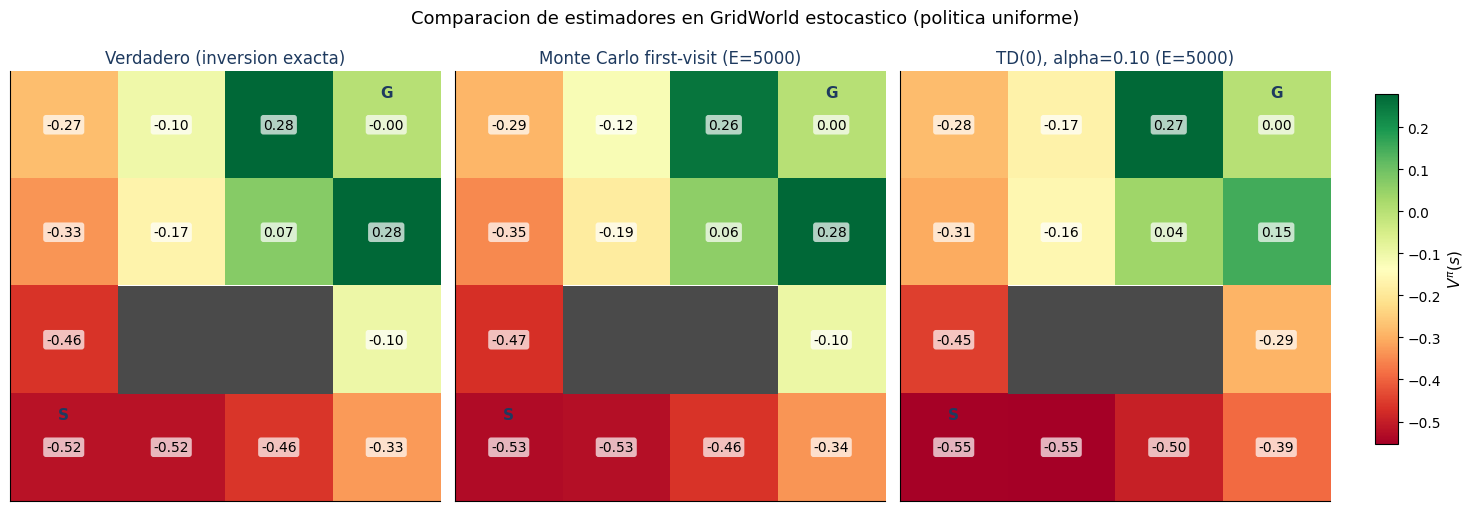

In [18]:
def dibujar_gridworld_valores(env, valores, ax, titulo, cmap='RdYlGn', vmin=None, vmax=None):
    '''Dibuja el GridWorld con un heatmap de valores.'''
    if vmin is None:
        vmin = valores.min()
    if vmax is None:
        vmax = valores.max()

    matriz = np.full((env.n_filas, env.n_cols), np.nan)
    for s in env.estados:
        if s in env.muros:
            continue
        matriz[s[0], s[1]] = valores[env.idx_estado[s]]

    im = ax.imshow(matriz, cmap=cmap, vmin=vmin, vmax=vmax)

    for r in range(env.n_filas):
        for c in range(env.n_cols):
            if (r, c) in env.muros:
                ax.add_patch(patches.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                                facecolor=COLOR_GRAY, zorder=2))
                continue
            v = matriz[r, c]
            ax.text(c, r, f'{v:.2f}', ha='center', va='center',
                    fontsize=10, color='black',
                    bbox=dict(boxstyle='round,pad=0.2',
                              facecolor='white', alpha=0.7,
                              edgecolor='none'))
            if (r, c) == env.inicio:
                ax.text(c, r - 0.3, 'S', ha='center', va='center',
                        fontsize=11, fontweight='bold', color=COLOR_NAVY)
            elif (r, c) == env.meta:
                ax.text(c, r - 0.3, 'G', ha='center', va='center',
                        fontsize=11, fontweight='bold', color=COLOR_NAVY)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(titulo)
    return im


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

vmin = min(V_verdadero_gw.min(), V_mc_gw.min(), V_td_gw.min())
vmax = max(V_verdadero_gw.max(), V_mc_gw.max(), V_td_gw.max())

im1 = dibujar_gridworld_valores(gw, V_verdadero_gw, axes[0],
                                'Verdadero (inversion exacta)',
                                vmin=vmin, vmax=vmax)
im2 = dibujar_gridworld_valores(gw, V_mc_gw, axes[1],
                                f'Monte Carlo first-visit (E={N_EP_GW})',
                                vmin=vmin, vmax=vmax)
im3 = dibujar_gridworld_valores(gw, V_td_gw, axes[2],
                                f'TD(0), alpha=0.10 (E={N_EP_GW})',
                                vmin=vmin, vmax=vmax)

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im3, cax=cbar_ax, label=r'$V^\pi(s)$')

plt.suptitle('Comparacion de estimadores en GridWorld estocastico (politica uniforme)',
             fontsize=13, y=1.02)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

/tmp/ipykernel_849/4186125209.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


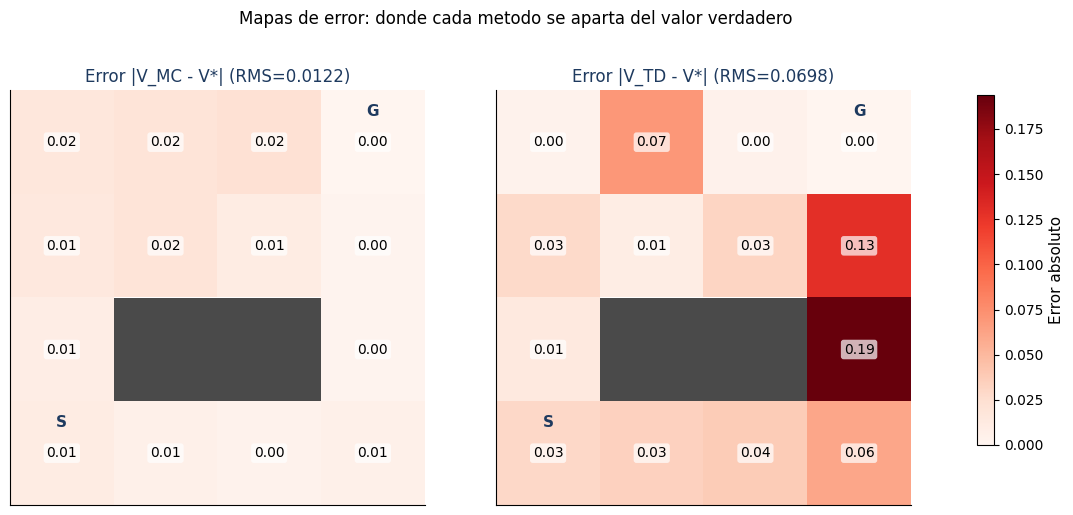


Error RMS Monte Carlo: 0.0122
Error RMS TD(0):       0.0698


In [19]:
# Mapas de error absoluto
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

err_mc = np.abs(V_mc_gw - V_verdadero_gw)
err_td = np.abs(V_td_gw - V_verdadero_gw)

vmax_err = max(err_mc.max(), err_td.max())

im1 = dibujar_gridworld_valores(gw, err_mc, axes[0],
                                f'Error |V_MC - V*| (RMS={np.sqrt((err_mc**2).mean()):.4f})',
                                cmap='Reds', vmin=0, vmax=vmax_err)
im2 = dibujar_gridworld_valores(gw, err_td, axes[1],
                                f'Error |V_TD - V*| (RMS={np.sqrt((err_td**2).mean()):.4f})',
                                cmap='Reds', vmin=0, vmax=vmax_err)

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im2, cax=cbar_ax, label='Error absoluto')

plt.suptitle('Mapas de error: donde cada metodo se aparta del valor verdadero',
             fontsize=12, y=1.02)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

print(f'\nError RMS Monte Carlo: {np.sqrt((err_mc**2).mean()):.4f}')
print(f'Error RMS TD(0):       {np.sqrt((err_td**2).mean()):.4f}')

## Ejercicios propuestos

Los siguientes ejercicios extienden las implementaciones de este cuaderno. El plazo de entrega del componente evaluado de la Unidad 2 es el **25 de mayo, 23:59 hs**.

### Ejercicios obligatorios (formales)

1. **Ejercicio teórico 1.** Demuestre que el estimador first-visit MC del valor de un estado $s$ es insesgado. Identifique con precisión la fuente de aleatoriedad implicada en la esperanza.

2. **Ejercicio teórico 2.** Pruebe que la actualización TD(0) con pasos $\alpha_n(s)$ que verifican Robbins-Monro converge en esperanza al punto fijo $V^\pi$. *(Sugerencia: trate la actualización como un esquema estocástico sobre el operador $\mathcal{T}^\pi$ y emplee el lema de Robbins-Siegmund.)*

3. **Ejercicio computacional 1.** Reproduzca la figura 6.2 de Sutton & Barto (Bloque 4 de este cuaderno) variando el número de réplicas a $N = 200$ y agregue una grilla más densa de $\alpha$. Discuta si el cruce de las curvas MC y TD se mantiene.

4. **Ejercicio computacional 2.** Compare empíricamente la sensibilidad de MC y TD(0) al paso $\alpha$ sobre GridWorld estocástico. ¿Existe un $\alpha^*$ que minimice el error RMS asintótico? Documente sus hallazgos con figuras y comentarios.

### Ejercicios opcionales (de profundización)

5. **Ejercicio integrador.** Implemente un *n-step TD* (versión intermedia entre TD(0) y MC):

   $$G_t^{(n)} = R_{t+1} + \gamma R_{t+2} + \dots + \gamma^{n-1} R_{t+n} + \gamma^n \widehat{V}(S_{t+n}).$$

   Compare el error final como función de $n \in \{1, 2, 4, 8, 16\}$ sobre el random walk. ¿Encuentra el valor óptimo de $n$ predicho por Sutton & Barto?

6. **Ejercicio teórico avanzado.** Discuta por qué en el régimen *batch* (con datos congelados) Monte Carlo converge al estimador de mínimos cuadrados sobre las muestras observadas, mientras que TD(0) converge al estimador de máxima verosimilitud del MDP empírico. *(Sugerencia: lea Sutton & Barto §6.3 y reescriba el resultado en notación estadística.)*

---

### Referencias del cuaderno

* Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2.ª ed.). MIT Press. Capítulos 5 y 6.
* Zhao, S. (2024). *Mathematical Foundations of Reinforcement Learning*. Springer. Capítulos 5 y 7.
* Bertsekas, D. P., & Tsitsiklis, J. N. (1996). *Neuro-Dynamic Programming*. Athena Scientific.

---

*Cuaderno preparado para la Clase 3 del curso «Aprendizaje por Refuerzo: Fundamentos y Aplicaciones», Universidad Austral, mayo de 2026.*